In [1]:
from transformers import AutoImageProcessor
from modeling_vit_2 import ViTForImageClassification
from PIL import Image
import requests
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
import tqdm
import pandas as pd
import numpy as np

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
processor = AutoImageProcessor.from_pretrained("facebook/deit-base-patch16-224")
model = ViTForImageClassification.from_pretrained("facebook/deit-base-patch16-224").to(device).eval()

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


In [4]:
ds = load_dataset("pouya-haghi/imagenet-1k")

In [5]:
rows = open("img-labels.txt").read().split('\n')
label_to_name = {int(row.split(', ')[0]): row.split(', ')[1] for row in rows}

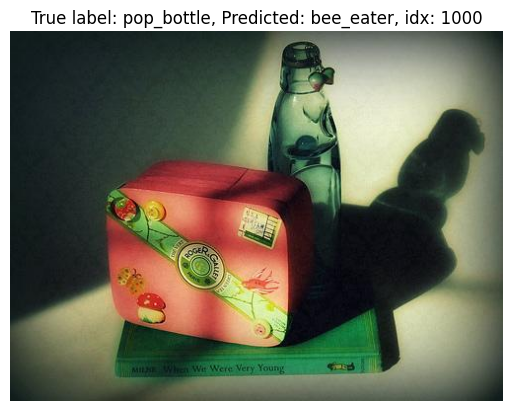

In [6]:
# Select one image from the training set
rand_pos = np.random.randint(0, len(ds['train']))
sample = ds['train'][rand_pos]
image = sample['image']
label = sample['label']

# Preprocess and move to device
inputs = processor(images=image.convert("RGB"), return_tensors="pt")
inputs = {k: v.to(device) for k, v in inputs.items()}

# Predict
with torch.no_grad():
    outputs = model(**inputs)
    pred_label = outputs.logits.argmax(-1).item()

# Show image and prediction
plt.imshow(image)
plt.axis('off')
plt.title(f"True label: {label_to_name[label]}, Predicted: {label_to_name[pred_label]}, idx: {rand_pos}")
plt.show()

In [9]:
batch_size = 16

def evaluate(batch_size=8, progress_bar=True):
    correct = 0
    train_ds = ds['train']

    iterator = range(0, len(train_ds), batch_size)
    if progress_bar:
        iterator = tqdm.tqdm(iterator)

    for i in iterator:
        batch = train_ds[i : i + batch_size]
        # Convert all images to RGB to handle grayscale images
        images = [img.convert("RGB") for img in batch['image']]
        inputs = processor(images=images, return_tensors="pt")
        inputs = {k: v.to(device) for k, v in inputs.items()}
          # Example ablation at layer 9 attention
        with torch.no_grad():
            outputs = model(**inputs)
        
        predictions = outputs.logits.argmax(-1).cpu()
        labels = torch.tensor(batch['label']).cpu()
        correct += (predictions == labels).sum().item()

    accuracy = correct / len(train_ds)
    return np.round(accuracy * 100, 2)

In [10]:
baseline_acc = evaluate(batch_size=batch_size)
print(f"Baseline Accuracy: {baseline_acc:.4f}")

100%|██████████| 64/64 [00:06<00:00, 10.54it/s]

Baseline Accuracy: 80.1800


In [ ]:
def skip_layer_atten(module, input, output):
    self = module
    hidden_states, head_mask = input
    # hidden_states_norm = self.layernorm_before(hidden_states)
    # attention_output = self.attention(hidden_states_norm, head_mask)

    # # first residual connection
    # hidden_states = attention_output + hidden_states

    # in ViT, layernorm is also applied after self-attention
    layer_output = self.layernorm_after(hidden_states)
    layer_output = self.intermediate(layer_output)

    # second residual connection is done here
    layer_output = self.output(layer_output, hidden_states) + hidden_states

    return layer_output

def skip_layer_ffn(module, input, output):
    self = module
    hidden_states, head_mask = input
    hidden_states_norm = self.layernorm_before(hidden_states)
    attention_output = self.attention(hidden_states_norm, head_mask)

    # first residual connection
    hidden_states = attention_output + hidden_states

    # # in ViT, layernorm is also applied after self-attention
    # layer_output = self.layernorm_after(hidden_states)
    # layer_output = self.intermediate(layer_output)

    # # second residual connection is done here
    # layer_output = self.output(layer_output, hidden_states) + hidden_states

    return hidden_states

def skip_layer_attention_residual(module, input, output):
    self = module
    hidden_states, head_mask = input
    hidden_states_norm = self.layernorm_before(hidden_states)
    attention_output = self.attention(hidden_states_norm, head_mask)

    # first residual connection
    hidden_states = attention_output #+ hidden_states

    # in ViT, layernorm is also applied after self-attention
    layer_output = self.layernorm_after(hidden_states)
    layer_output = self.intermediate(layer_output)

    # second residual connection is done here
    layer_output = self.output(layer_output, hidden_states) + hidden_states

    return hidden_states

def skip_layer_ffn_residual(module, input, output):
    self = module
    hidden_states, head_mask = input
    hidden_states_norm = self.layernorm_before(hidden_states)
    attention_output = self.attention(hidden_states_norm, head_mask)

    # first residual connection
    hidden_states = attention_output + hidden_states

    # in ViT, layernorm is also applied after self-attention
    layer_output = self.layernorm_after(hidden_states)
    layer_output = self.intermediate(layer_output)

    # second residual connection is done here
    layer_output = self.output(layer_output, None) # + hidden_states

    return hidden_states

def skip_layer_ffn_residual_no_residual_attention(module, input, output):
    self = module
    hidden_states, head_mask = input
    hidden_states_norm = self.layernorm_before(hidden_states)
    attention_output = self.attention(hidden_states_norm, head_mask)

    # first residual connection
    hidden_states = attention_output #+ hidden_states

    # in ViT, layernorm is also applied after self-attention
    layer_output = self.layernorm_after(hidden_states)
    layer_output = self.intermediate(layer_output)

    # second residual connection is done here
    layer_output = self.output(layer_output, None) #+ hidden_states

    return hidden_states

In [12]:
def apply_hook_condition(layer_idx, **kwargs):
    max_layer = kwargs['max_layer']
    target_layer = kwargs.get('target_layer', max_layer - 1)
    return layer_idx == target_layer


In [13]:
def run_experiment(condition_fn, hook_fn, batch_size=16, progress_bar=True):
    handles = []
    for layer_idx in range(model.config.num_hidden_layers):
        if condition_fn(layer_idx):
            handle = model.vit.encoder.layer[layer_idx].register_forward_hook(hook_fn)
            handles.append(handle)

    baseline_acc = evaluate(batch_size= batch_size, progress_bar=progress_bar)

    for handle in handles:
        handle.remove()

    return baseline_acc

In [14]:
max_layer = model.config.num_hidden_layers
hook_fns = [skip_layer_atten, skip_layer_attention_residual, skip_layer_ffn, skip_layer_ffn_residual, skip_layer_ffn_residual_no_residual_attention]
results = []
for i in range(max_layer):
    for hook_fn in hook_fns:
        condition_fn = lambda layer_idx, target_layer=i, max_layer=max_layer: apply_hook_condition(layer_idx, target_layer=target_layer, max_layer=max_layer)
        acc = run_experiment(condition_fn, hook_fn, batch_size=batch_size, progress_bar=False)
        results.append({
            'layer': i,
            'hook': hook_fn.__name__,
            'accuracy': acc
        })
    print(f"Completed layer {i}")

    

Completed layer 0
Completed layer 1
Completed layer 2
Completed layer 3
Completed layer 4
Completed layer 5
Completed layer 6
Completed layer 7
Completed layer 8
Completed layer 9
Completed layer 10
Completed layer 11


In [15]:
# to DataFrame
results_df = pd.DataFrame(results)
results_df.to_csv("vit_hook_results.csv", index=False)

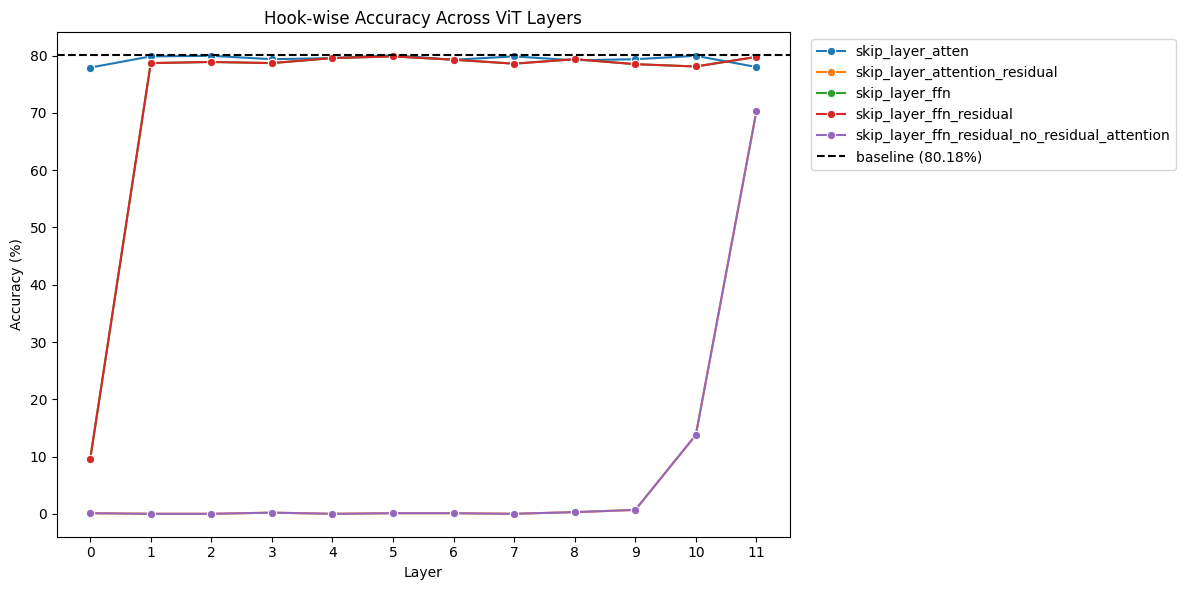

In [27]:
# Convert results to DataFrame
results_df = pd.DataFrame(results).sort_values(["hook", "layer"])
# filter the skip_layer_ffn_residual_no_residual_attention and skip_layer_ffn_residual
# results_df = results_df[~results_df['hook'].isin(['skip_layer_ffn_residual_no_residual_attention', 'skip_layer_attention_residual', 'skip_layer_ffn'])]
# Plot hook performance across layers
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=results_df,
    x="layer",
    y="accuracy",
    hue="hook",
    marker="o"
)

# Baseline reference
plt.axhline(baseline_acc, color="black", linestyle="--", linewidth=1.5, label=f"baseline ({baseline_acc:.2f}%)")

plt.title("Hook-wise Accuracy Across ViT Layers")
plt.xlabel("Layer")
plt.ylabel("Accuracy (%)")
plt.xticks(sorted(results_df["layer"].unique()))
# plt.ylim(75, 85)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()